# Часть 1 Бустинг (5 баллов)


В этой части будем предсказывать зарплату data scientist-ов в зависимости от ряда факторов с помощью градиентного бустинга.


В датасете есть следующие признаки:

- work_year: The number of years of work experience in the field of data science.

- experience_level: The level of experience, such as Junior, Senior, or Lead.

- employment_type: The type of employment, such as Full-time or Contract.

- job_title: The specific job title or role, such as Data Analyst or Data Scientist.

- salary: The salary amount for the given job.

- salary_currency: The currency in which the salary is denoted.

- salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

- employee_residence: The country or region where the employee resides.

- remote_ratio: The percentage of remote work offered in the job.

- company_location: The location of the company or organization.

- company_size: The company's size is categorized as Small, Medium, or Large.


In [21]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")

import warnings
warnings.filterwarnings("ignore")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка


- Разделите выборку на train, val, test (80%, 10%, 10%)
- Выдерите salary_in_usd в качестве таргета
- Найдите и удалите признак, из-за которого возможен лик в данных


In [22]:
from sklearn.model_selection import train_test_split

X, y = df.drop(["salary", "salary_in_usd"], axis=1), df["salary_in_usd"]

In [23]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=len(X) // 10, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=len(X) // 10, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((3005, 9), (375, 9), (375, 9))

> Удаляем признак `salary` т.к. это тот же таргет только в другой валюте (и то не всегда)


## Задание 2 (0.5 балла) Линейная модель


- Закодируйте категориальные признаки с помощью OneHotEncoder
- Обучите модель линейной регрессии
- Оцените качество через MAPE и RMSE


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(["object"]).columns.to_list()
categorical_features

['experience_level',
 'employment_type',
 'job_title',
 'salary_currency',
 'employee_residence',
 'company_location',
 'company_size']

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
], remainder="passthrough")

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
X_val_prep = preprocessor.transform(X_val)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [26]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")

MAPE: 0.4635068713053805
RMSE: 52022.44847429278


## Задание 3 (0.5 балла) XGboost


Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.


In [27]:
results = dict()

In [28]:
from xgboost import XGBRegressor
from itertools import product
from tqdm.notebook import tqdm
import numpy as np
import random

best_rmse = float("inf")
best_params = None

random.seed(42)
iter_count = 1000

for _ in tqdm(range(iter_count), "Random search"):
    params = {
        "max_depth": random.randint(3, 10),
        "learning_rate": float(np.exp(np.random.uniform(np.log(0.01), np.log(0.3)))),
        "n_estimators": random.randint(300, 2000),
        "gamma": random.uniform(0, 5),
        "subsample": random.uniform(0.5, 1.0),
        "colsample_bytree": random.uniform(0.5, 1.0),
        "reg_lambda": float(np.exp(np.random.uniform(np.log(1e-3), np.log(10)))),
        "reg_alpha": float(np.exp(np.random.uniform(np.log(1e-8), np.log(1)))),
    }
    
    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        early_stopping_rounds=50,
    )
    
    model.fit(
        X_train_prep,
        y_train,
        eval_set=[(X_val_prep, y_val)],
        verbose=False
    )
    
    y_val_pred = model.predict(X_val_prep)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print(f"Best RMSE: {best_rmse}")
print(f"Best params: {best_params}")

Random search:   0%|          | 0/1000 [00:00<?, ?it/s]

Best RMSE: 49650.41015625
Best params: {'max_depth': 9, 'learning_rate': 0.1444514780462886, 'n_estimators': 1630, 'gamma': 0.40157660289724506, 'subsample': 0.6642827944917281, 'colsample_bytree': 0.8371787475770047, 'reg_lambda': 0.9106040478843596, 'reg_alpha': 0.09044346566007314}


In [29]:
import time

start = time.perf_counter()

xgb = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    early_stopping_rounds=50,
).fit(
    X_train_prep, y_train,
    eval_set=[(X_val_prep, y_val)],
    verbose=False
)

train_time = time.perf_counter() - start

In [30]:
start = time.perf_counter()

y_test_pred = xgb.predict(X_test_prep)

predict_time = time.perf_counter() - start

mape = mean_absolute_percentage_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

print(f"Train time: {train_time:.4f} sec")
print(f"Predict time: {predict_time:.4f} sec")

results["XGBoost"] = {
    "mape": mape,
    "rmse": rmse,
    "train_time": train_time,
    "predict_time": predict_time,
}

MAPE: 0.41166895627975464
RMSE: 50213.1640625
Train time: 0.2302 sec
Predict time: 0.0016 sec


## Задание 4 (1 балл) CatBoost


Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.


In [31]:
from catboost import CatBoostRegressor

best_rmse = float("inf")
best_params = None

random.seed(42)
iter_count = 1000

for _ in tqdm(range(iter_count), "Random search"):
    params = {
        "depth": random.randint(3, 10),
        "learning_rate": float(np.exp(np.random.uniform(np.log(0.01), np.log(0.3)))),
        "iterations": random.randint(25, 200),
        "l2_leaf_reg": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
        "random_strength": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
    }
    
    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
    )
    
    model.fit(
        X_train_prep, y_train,
        eval_set=[(X_val_prep, y_val)],
        verbose=False,
        early_stopping_rounds=50,
    )
    
    y_val_pred = model.predict(X_val_prep)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print(f"Best RMSE: {best_rmse}")
print(f"Best params: {best_params}")

Random search:   0%|          | 0/1000 [00:00<?, ?it/s]

Best RMSE: 49848.5824741484
Best params: {'depth': 9, 'learning_rate': 0.2576338442184942, 'iterations': 124, 'l2_leaf_reg': 1.4293611199398706, 'random_strength': 7.883272394006225e-07}


In [32]:
start = time.perf_counter()

cb = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    random_seed=42,
).fit(
    X_train_prep, y_train,
    eval_set=[(X_val_prep, y_val)],
    verbose=False,
    early_stopping_rounds=50,
)

train_time = time.perf_counter() - start

In [33]:
start = time.perf_counter()

y_test_pred = cb.predict(X_test_prep)

predict_time = time.perf_counter() - start

mape = mean_absolute_percentage_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

print(f"Train time: {train_time:.4f} sec")
print(f"Predict time: {predict_time:.4f} sec")

results["CatBoost"] = {
    "mape": mape,
    "rmse": rmse,
    "train_time": train_time,
    "predict_time": predict_time,
}

MAPE: 0.40279074920489133
RMSE: 49870.73508897595
Train time: 0.1290 sec
Predict time: 0.0012 sec


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?


In [34]:
from catboost import Pool

train_pool = Pool(
    X_train,
    y_train,
    cat_features=categorical_features,
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=categorical_features,
)

val_pool = Pool(
    X_val,
    y_val,
    cat_features=categorical_features,
)

In [35]:
best_rmse = float("inf")
best_params = None

random.seed(42)
iter_count = 1000

for _ in tqdm(range(iter_count), "Random search"):
    params = {
        "depth": random.randint(3, 10),
        "learning_rate": float(np.exp(np.random.uniform(np.log(0.01), np.log(0.3)))),
        "iterations": random.randint(25, 200),
        "l2_leaf_reg": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
        "random_strength": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
    }
    
    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
    )
    
    model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=False,
        early_stopping_rounds=50,
    )
    
    y_val_pred = model.predict(val_pool)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print(f"Best RMSE: {best_rmse}")
print(f"Best params: {best_params}")

Random search:   0%|          | 0/1000 [00:00<?, ?it/s]

Best RMSE: 50191.30121307632
Best params: {'depth': 6, 'learning_rate': 0.1639389338002932, 'iterations': 102, 'l2_leaf_reg': 0.12166893558501646, 'random_strength': 1.1022514487410513}


In [36]:
start = time.perf_counter()

cb = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    random_seed=42,
).fit(
    train_pool,
    eval_set=val_pool,
    verbose=False,
    early_stopping_rounds=50,
)

train_time = time.perf_counter() - start

In [37]:
start = time.perf_counter()

y_test_pred = cb.predict(test_pool)

predict_time = time.perf_counter() - start

mape = mean_absolute_percentage_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

print(f"Train time: {train_time:.4f} sec")
print(f"Predict time: {predict_time:.4f} sec")

results["CatBoost (with Pool)"] = {
    "mape": mape,
    "rmse": rmse,
    "train_time": train_time,
    "predict_time": predict_time,
}

MAPE: 0.43323990945179064
RMSE: 51438.512339373694
Train time: 0.1014 sec
Predict time: 0.0004 sec


**Ответ:** Стало хуже по времени обучения, т.к. CatBoost тратит время на внутреннюю обработку категориальных признаков. Время предсказания уменьшилось, вероятно, из-за внутренних оптимизаций при работе с категориальными признаками. Ухудшение качества может быть связано с тем, что One-Hot-Encoding и так хорошо передавал информацию модели, и усложнение не дало прироста, а наоборот ухудшило значение метрик.


## Задание 5 (0.5 балла) LightGBM


И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [38]:
from lightgbm import LGBMRegressor, early_stopping

best_rmse = float("inf")
best_params = None

random.seed(42)
iter_count = 1000

for _ in tqdm(range(iter_count), "Random search"):
    params = {
        "max_depth": random.randint(3, 10),
        "learning_rate": float(np.exp(np.random.uniform(np.log(0.01), np.log(0.3)))),
        "n_estimators": random.randint(25, 200),
        "num_leaves": random.randint(8, 128),
        "min_child_samples": random.randint(5, 100),
        "subsample": random.uniform(0.5, 1.0),
        "colsample_bytree": random.uniform(0.5, 1.0),
        "reg_lambda": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
        "reg_alpha": float(np.exp(np.random.uniform(np.log(1e-8), np.log(10)))),
    }
    
    model = LGBMRegressor(
        **params,
        objective="regression",
        metric="rmse",
        random_state=42,
        verbose=-1,
    )
    
    model.fit(
        X_train_prep, y_train,
        eval_set=[(X_val_prep, y_val)],
        callbacks=[
            early_stopping(50, verbose=False)
        ]
    )
    
    y_val_pred = model.predict(X_val_prep)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print(f"Best RMSE: {best_rmse}")
print(f"Best params: {best_params}")

Random search:   0%|          | 0/1000 [00:00<?, ?it/s]

Best RMSE: 50101.78048000201
Best params: {'max_depth': 10, 'learning_rate': 0.030952296763774208, 'n_estimators': 172, 'num_leaves': 108, 'min_child_samples': 36, 'subsample': 0.6629431187214527, 'colsample_bytree': 0.6401500732321088, 'reg_lambda': 0.02613692087370568, 'reg_alpha': 0.00014936220058167982}


In [39]:
start = time.perf_counter()

lgbm = LGBMRegressor(
    **best_params,
    objective="regression",
    metric="rmse",
    random_seed=42,
    verbose=-1,
).fit(
    X_train_prep, y_train,
    eval_set=[(X_val_prep, y_val)],
)

train_time = time.perf_counter() - start

In [40]:
start = time.perf_counter()

y_test_pred = lgbm.predict(X_test_prep)

predict_time = time.perf_counter() - start

mape = mean_absolute_percentage_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")

print(f"Train time: {train_time:.4f} sec")
print(f"Predict time: {predict_time:.4f} sec")

results["LightGBM"] = {
    "mape": mape,
    "rmse": rmse,
    "train_time": train_time,
    "predict_time": predict_time,
}

MAPE: 0.3945855335715289
RMSE: 50703.13383371238
Train time: 0.7751 sec
Predict time: 0.0018 sec


## Задание 6 (2 балла) Сравнение и выводы


Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?


In [41]:
results_df = pd.DataFrame(results).T

results_df = results_df.rename(columns={
    "mape": "MAPE",
    "rmse": "RMSE",
    "train_time": "Train time, sec",
    "predict_time": "Predict time, sec",
})

results_df.style.format({
    "MAPE": "{:.4f}",
    "RMSE": "{:.4f}",
    "Train time, sec": "{:.4f}",
    "Predict time, sec": "{:.4f}",
}).highlight_min(axis=0)

,MAPE,RMSE,"Train time, sec","Predict time, sec"
XGBoost,0.4117,50213.1641,0.2302,0.0016
CatBoost,0.4028,49870.7351,0.1290,0.0012
CatBoost (with Pool),0.4332,51438.5123,0.1014,0.0004
LightGBM,0.3946,50703.1338,0.7751,0.0018


**Ответ:** Лучший результат по MAPE показал `LightGBM`, а по RMSE - `CatBoost`. Худшие результаты по качеству предсказаний получились у `CatBoost с использованием Pool`.

По времени обучения выиграл `CatBoost с Pool`. Это может означать, что либо сам алгоритм на этих данных работал быстро, либо early stopping сработал раньше остальных. `LightGBM` считается быстрым алгоритмом, но в этом случае обучался дольше всех. Вероятно для него early stopping не сработал, либо сработал слишком поздно.

По скорости предсказания самым быстрым также является `CatBoost с Pool`. Это может быть связано со внутренними оптимизациями при обработке категориальных признаков. Проиграл по этому параметру также `LightGBM`. Все абсолютные значения времени предсказания у моделей небольшие, поэтому эти различия не будут критичными.

Из основных гиперпараметров, которые я подбирал:

**XGBoost**: `n_estimators` (количество деревьев), `learning_rate` (скорость обучения), `max_depth` (максимальная глубина дерева), `subsample` (доля объектов для обучения каждого дерева), `colsample_bytree` (доля признаков для каждого дерева), `gamma` (минимальное улучшение качества для нового разбиения), `reg_lambda` и `reg_alpha` (L2- и L1-регуляризация).

**CatBoost**: `iterations` (количество деревьев), `learning_rate` (скорость обучения), `depth` (глубина дерева, аналог max_depth), `l2_leaf_reg` (L2-регуляризация), `random_strength` (случайность при выборе разбиений).

**LightGBM**: `n_estimators` (количество деревьев), `learning_rate` (скорость обучения), `max_depth` (ограничение глубины дерева), `num_leaves` (максимальное число листьев в дереве), `min_child_samples` (минимальное число объектов в листе), `subsample` (доля объектов), `colsample_bytree` (доля признаков), `reg_lambda` и `reg_alpha` (L2- и L1-регуляризация). Главное отличие `LightGBM` - параметры `num_leaves` и `min_child_samples`, потому что модель строит деревья leaf-wise, то есть расширяет наиболее выгодные листья.

Гиперпараметры моделей отвечают примерно за одно и то же: количество деревьев, скорость обучения, сложность деревьев и регуляризацию. Отличаются названия и некоторые специфические настройки: у `XGBoost` есть `gamma` для контроля новых разбиений, у `CatBoost` - `random_strength`, а у `LightGBM` особенно важным является `num_leaves`.


# Часть 2 Кластеризация (5 баллов)


Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [102]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.


## Задание 1 (0.5 балла) Подготовка


Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.


In [103]:
ratings = ratings.T
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
saves the day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029212,NaN


Выкиньте строку под названием `user`.


In [104]:
ratings = ratings.drop(["user"])

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)

Доля исполнителя в музыке, прослушанной пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.


In [105]:
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
mewithoutyou,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.277464,0.0


## Задание 2 (0.5 балла) Первая кластеризация


Примените KMeans с 5ю кластерами, сохраните полученные лейблы


In [106]:
from sklearn.cluster import KMeans

km = KMeans(random_state=42, n_clusters=5).fit(ratings)
labels = km.labels_

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?


In [107]:
from collections import Counter
counts = Counter(labels)

for cluster, cnt in counts.items():
    print(f"Cluster {cluster} \t size: {cnt}")

Cluster 4 	 size: 1
Cluster 0 	 size: 115
Cluster 2 	 size: 1
Cluster 3 	 size: 882
Cluster 1 	 size: 1


**Ответ:** Получилось 3 кластера размером 1, что делает кластеризацию практически бесполезной. KMeans мог выдать такой результат, т.к. алгоритм чувствителен к выбросам и сильно отличающиеся объекты могли быть выделены в отдельные кластеры.


## Задание 3 (0.5 балла) Объяснение результатов


При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.


In [108]:
pred = km.predict(ratings)

for l in labels:
    matching = ratings[pred == l]
    if len(matching) == 1:
        print(f"Cluster: {l} \t Artist: {matching[0].index[0]}")

Cluster: 4 	 Artist: the beatles
Cluster: 2 	 Artist: niИ
Cluster: 1 	 Artist: 日dir en grey


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.


In [109]:
ratings.mean(axis=1).sort_values(ascending=False).head(3) # средняя доля прослушивания

the beatles           0.018369
radiohead             0.011851
deathcab for cutie    0.006543
dtype: float64

In [110]:
ratings.ne(0).mean(axis=1).head(3) # доля пользователей, которые слушают каждого. исполнителя

the beatles           0.3342
radiohead             0.2778
deathcab for cutie    0.1862
dtype: float64

**Ответ:** The Beatles сильно выделяется, т.к. это самая популярная группа в датасете по двум рассмотренным критериям и близких по популярности к ней нет.


## Задание 4 (0.5 балла) Улучшение кластеризации


Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.


In [111]:
from sklearn.preprocessing import normalize

normalized_ratings = pd.DataFrame(normalize(ratings, axis=1), index=ratings.index)
normalized_ratings

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
群星,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
agalloch,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
meshuggah,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?


In [112]:
km = KMeans(n_clusters=5, random_state=42).fit(normalized_ratings)
labels = km.labels_

counts = Counter(labels)
for cluster, cnt in counts.items():
    print(f"Cluster {cluster} \t size: {cnt}")

Cluster 3 	 size: 140
Cluster 4 	 size: 486
Cluster 1 	 size: 162
Cluster 0 	 size: 79
Cluster 2 	 size: 133


**Ответ** Стало лучше, т.к. размеры кластеров стали примерно одного порядка. Теперь например может получиться разделить исполнителей по жанрам.


## Задание 5 (1 балл) Центроиды


Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?


In [113]:
from scipy.spatial.distance import cosine

centroids = km.cluster_centers_

for i in range(centroids.shape[0]):
    artists = ratings[labels == i]
    centroid = centroids[i]
    
    top_idx = np.argsort(np.apply_along_axis(cosine, 1, artists, centroid))[:10]
    top_artists = artists.iloc[top_idx].index
    
    print(f"Cluster {i}:")
    for a in top_artists:
        print(f"\t{a}")

Cluster 0:
	nas
	jay-z
	kanye west
	lupe the gorilla
	a tribe called quest
	the roots featuring d'angelo
	gangstarr
	little brother
	lil' wayne
	murs and 9th wonder
Cluster 1:
	fall out boy
	the all-americian rejects
	paramore
	kelly clarkson
	john mayer
	the fray
	maroon5
	dashboard confesssional
	somethings corporate
	coldplay
Cluster 2:
	brand new
	blink-182
	alkaline trio
	against me!
	underoath
	descendents
	new found glory
	less than jake
	thrice
	chiodos
Cluster 3:
	the beatles
	the rolling stones
	dylan. bob
	who
	led zeppelin.
	miles davis.
	simon and garfunkel
	young, neil
	pink fluid
	velvet underground
Cluster 4:
	radiohead
	the arcade fire
	the shins
	sufjan stevens
	belle and sebastian
	broken social scene
	the pixies
	animal collective
	modest mouse
	spoon


**Ответ:** алгоритм неплохо разделил исполнителей на кластеры, которые можно воспринимать как жанры. В первом кластере рэпчик, в остальных - альтернатива, панк-рок и прочее.


## Задание 6 (1 балл) Визуализация


Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?


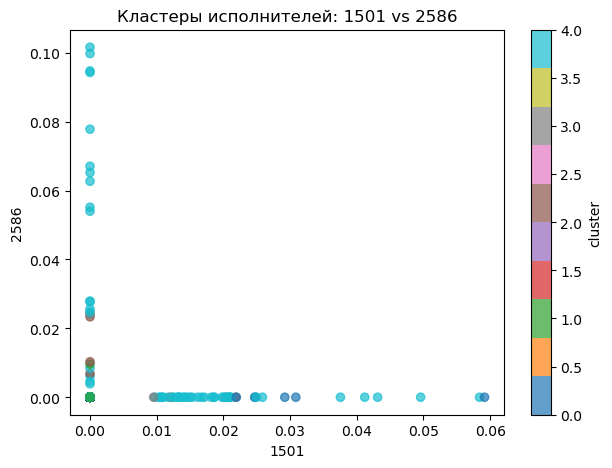

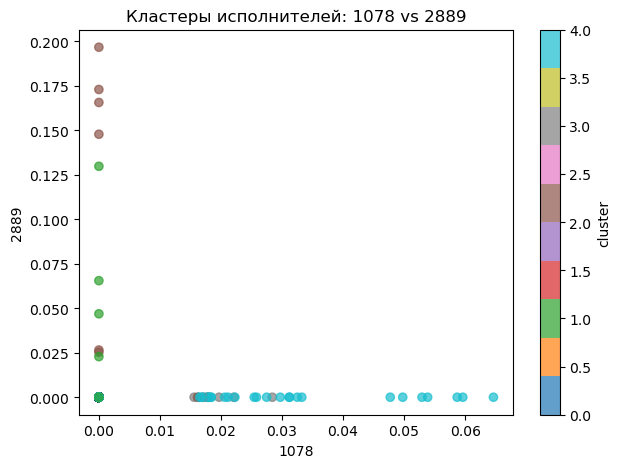

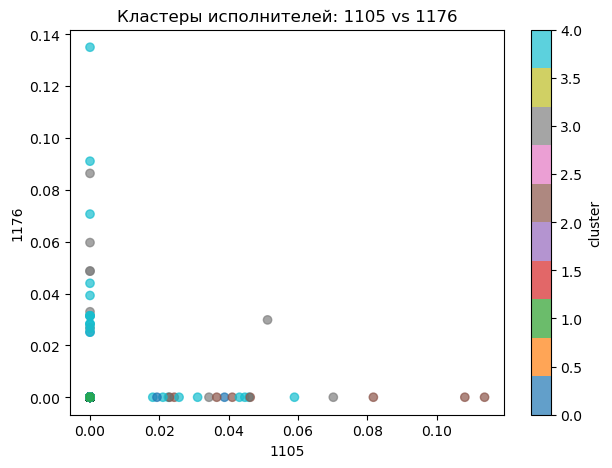

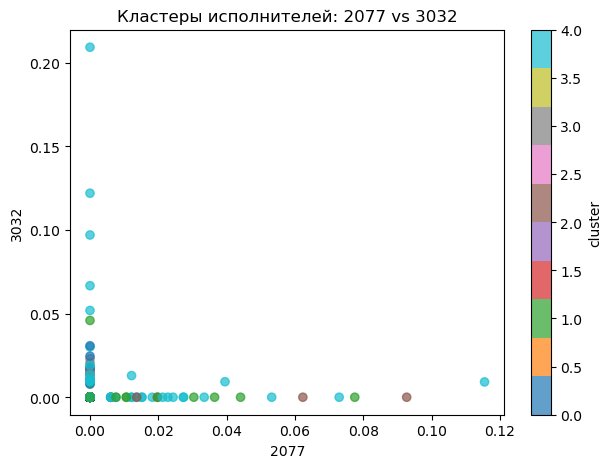

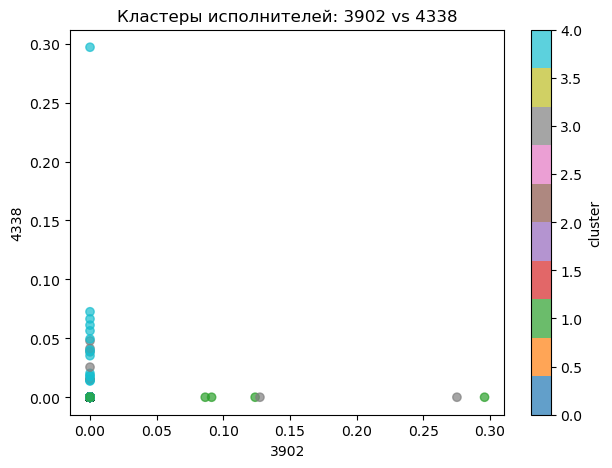

In [114]:
import matplotlib.pyplot as plt

np.random.seed(42)
user_pairs = [np.random.choice(ratings.columns, 2, replace=False) for _ in range(5)]

for user1, user2 in user_pairs:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        ratings[user1],
        ratings[user2],
        c=labels,
        cmap="tab10",
        alpha=0.7
    )

    plt.xlabel(str(user1))
    plt.ylabel(str(user2))
    plt.title(f"Кластеры исполнителей: {user1} vs {user2}")
    plt.colorbar(label="cluster")
    plt.show()

**Ответ:** Точки на графиках расположились вдоль осей координат, потому что данные сильно разрежены: большинство пользователей слушает малую часть исполнителей и для случайно выбранных пар пользователей почти не оказалось исполнителей, которых слушали бы оба пользователя. Из-за этого на таких проекциях плохо отделены кластеры и визуализацию трудно интерпретировать.


Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров


In [115]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42).fit_transform(normalized_ratings)

Text(0.5, 1.0, 'Визуализация кластеров с помощью t-SNE')

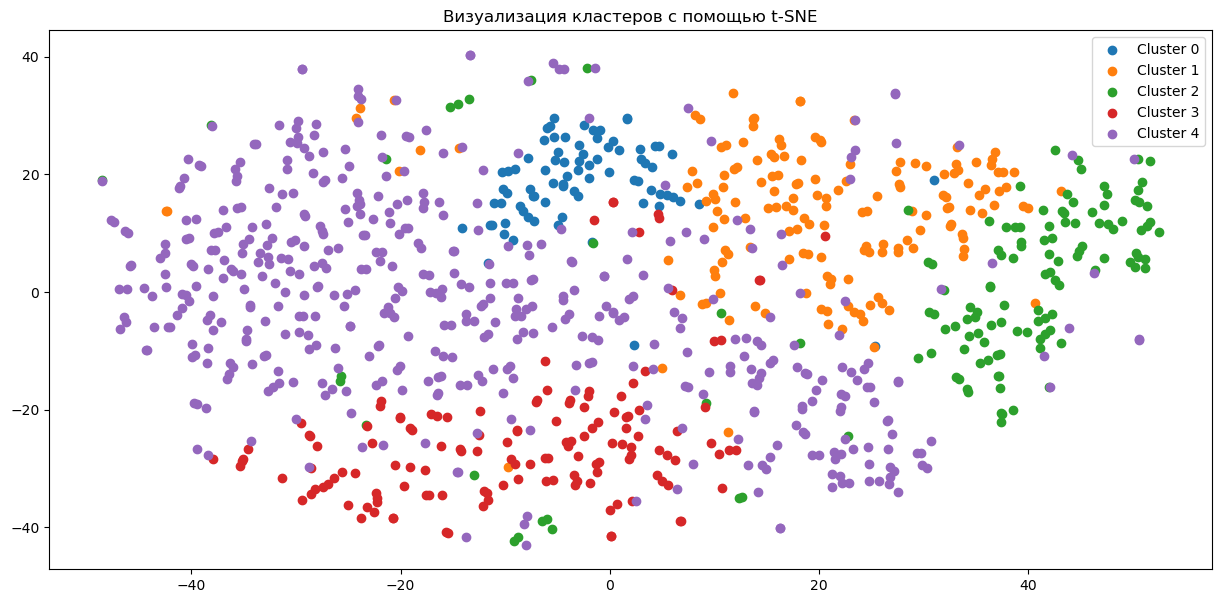

In [116]:
fig, ax = plt.subplots(figsize=(15, 7))

for cluster in np.unique(labels):
    ax.scatter(tsne[labels == cluster, 0], tsne[labels == cluster, 1], label=f"Cluster {cluster}")

ax.legend()
ax.set_title("Визуализация кластеров с помощью t-SNE")

## Задание 7 (1 балл) Подбор гиперпараметров


Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`


In [117]:
from sklearn.metrics import silhouette_score

cluster_counts = np.array(range(2, 101))
scores = np.array([
    silhouette_score(
        normalized_ratings,
        KMeans(
            n_clusters=cnt,
            random_state=42,
        ).fit_predict(normalized_ratings),
    )
    for cnt in cluster_counts
])

Text(0.5, 1.0, 'Silhouette score values \u200b\u200bfor different n_clusters')

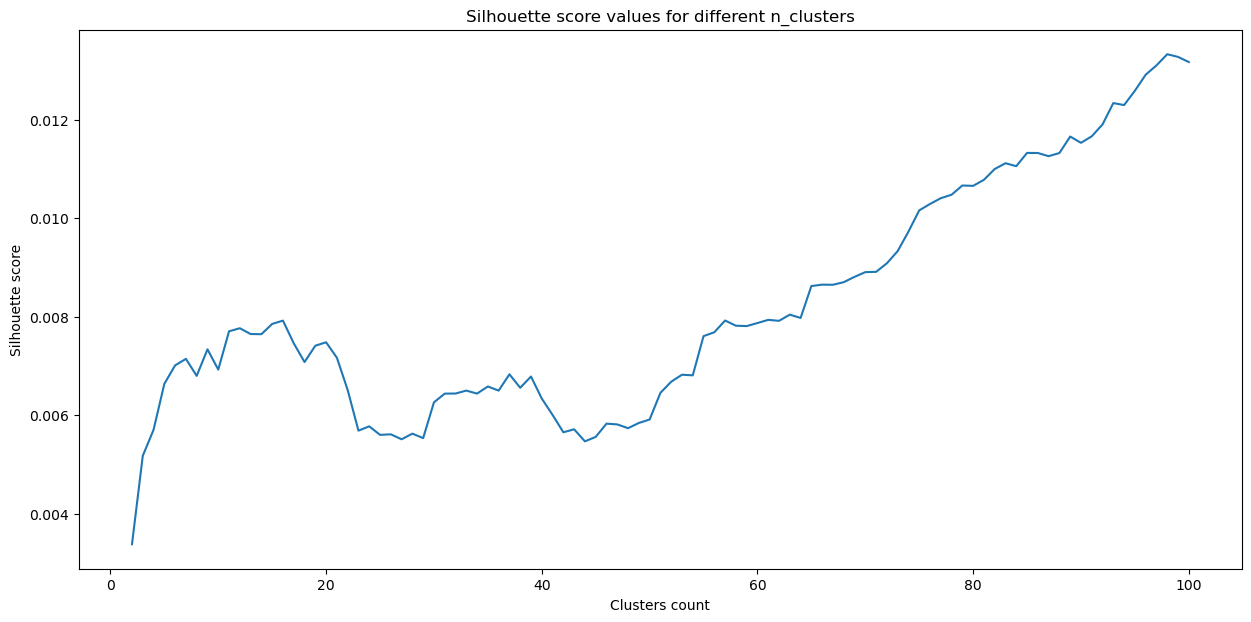

In [118]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(cluster_counts, scores)
ax.set_xlabel("Clusters count")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score values ​​for different n_clusters")

In [119]:
best_n = cluster_counts[scores.argmax()]

km = KMeans(n_clusters=best_n, random_state=42).fit(normalized_ratings)
labels = km.labels_

print(f"Max score with n_clusters = {best_n}")

Max score with n_clusters = 98


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.


In [120]:
from scipy.spatial.distance import cosine

centroids = km.cluster_centers_

for i in range(centroids.shape[0]):
    artists = ratings[labels == i]
    centroid = centroids[i]
    
    top_idx = np.argsort(np.apply_along_axis(cosine, 1, artists, centroid))[:10]
    top_artists = artists.iloc[top_idx].index
    
    print(f"Cluster {i}:")
    for a in top_artists:
        print(f"\t{a}")

Cluster 0:
	dr. dre
	the faint
	violent femmes
	margot and the nuclear so and sos
	owen
	the bloodhound gang
Cluster 1:
	john mayer
	matt nathanson
	gavin degraw
	jason mraz
	ray lamontagne
	joshua radin
	sara bareilles
	augustana
	maroon5
	o.a.r.
Cluster 2:
	white stripes
	beck
	the raconteurs
	spoon
	the pixies
	the strokes
	the flaming lips
	cake
	black rebel motorcycle club
	gorillaz
Cluster 3:
	fugazi
	jawbreaker
	sleater-kinney
	les savy fav
	capn jazz
	bad brains
	blonde redhead
	propagandhi
	the melvins
	gogol bordello
Cluster 4:
	ryan adams
	band of horses
	ryan adams and the cardinals
	rogue wave
	my morning jacket
	matt pond pa
	cloud cult
	the american analog set
	nada surf
	tv on the radio
Cluster 5:
	dj shadow
	rjd2
	amon tobin
	jedi mind tricks
	el-p
	aphex twin
	sublime
	moby*
	gnarls barkley
	soul coughing
Cluster 6:
	system of a down
	koЯn
	mudvayne
	limpt bizkit
	disturbed
	slipknot
	papa roach
	godsmack
	marilyn manson
	fort minor
Cluster 7:
	somethings corporate
	t

**Ответ:** алгоритм стал делить исполнителей на более узкие музыкальные направления. Например, кластер 73 очень хорошо выделил классическую музыку: Вивальди, Моцарт, Шопен и др. В целом при большем количестве кластеров разбиение стало более тонким. При этом некоторые кластеры оказались очень хорошо интерпретируемыми.

Сделайте t-SNE визуализацию полученной кластеризации.


Text(0.5, 1.0, 'Визуализация кластеров с помощью t-SNE')

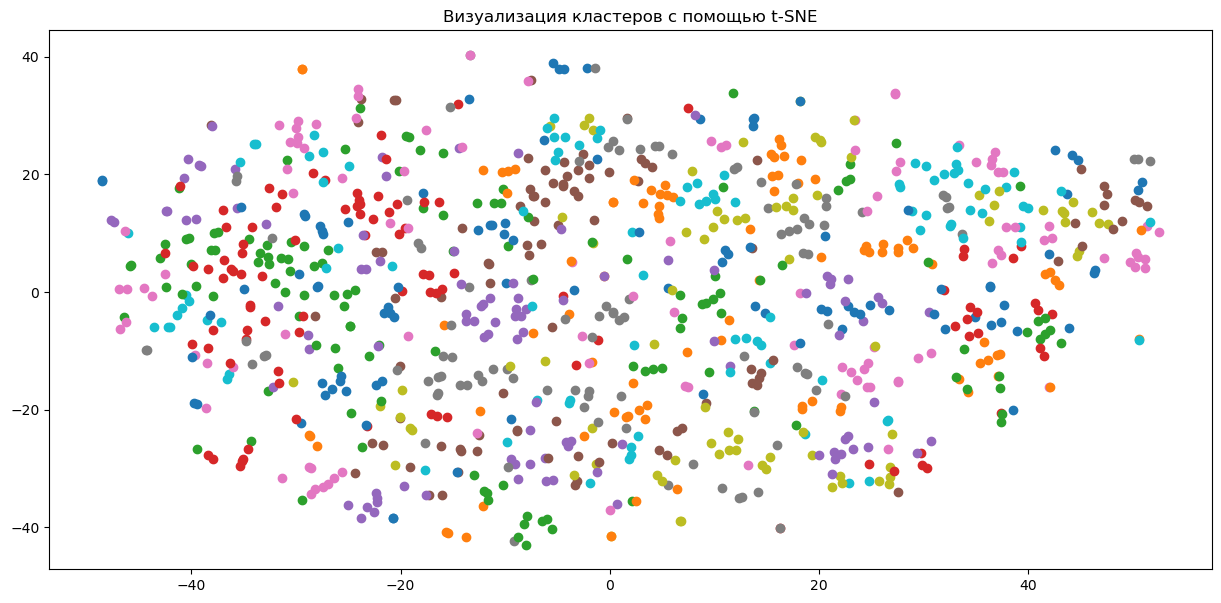

In [121]:
fig, ax = plt.subplots(figsize=(15, 7))

for cluster in np.unique(labels):
    ax.scatter(tsne[labels == cluster, 0], tsne[labels == cluster, 1], label=f"Cluster {cluster}")

ax.set_title("Визуализация кластеров с помощью t-SNE")

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?


Text(0.5, 1.0, 'Визуализация кластеров с помощью t-SNE')

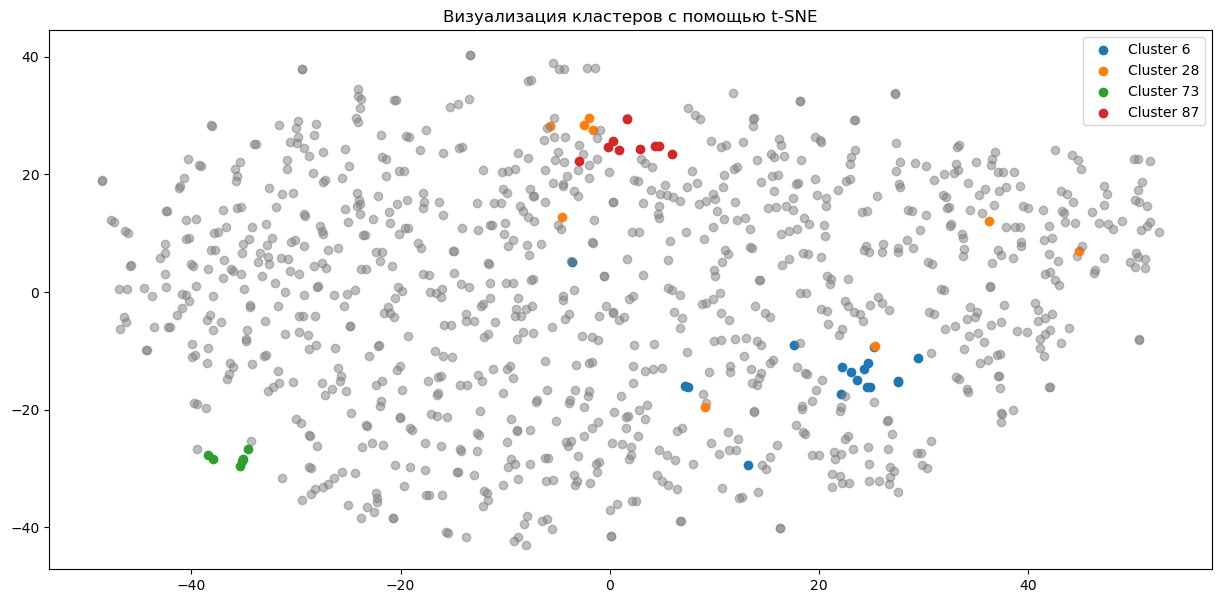

In [122]:
fig, ax = plt.subplots(figsize=(15, 7))

cluster_idx = [73, 28, 6, 87]
unique_labels = np.unique(labels)

for i in range(unique_labels.size):
    if i in cluster_idx:
        ax.scatter(tsne[labels == unique_labels[i], 0], tsne[labels == unique_labels[i], 1], label=f"Cluster {i}")
    else:
        ax.scatter(tsne[labels == unique_labels[i], 0], tsne[labels == unique_labels[i], 1], color="gray", alpha=0.5)

ax.legend()
ax.set_title("Визуализация кластеров с помощью t-SNE")

**Ответ:** кластеры 73 (классическая музыка) и 6 (ню метал) оказались в разных областях облака. Два близких по жанру кластера 87 и 28 (рэпчик) оказались далеко от прошлых двух, но рядом друг с другом. Это показывает, что t-SNE визуализация в целом отражает содержательную близость кластеров. При этом разделение не идеально: есть выбросы из кластера 28 рядом с кластером 6.